# Overfitting single intervals

## imports

In [25]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

PAL_MODALITIES = {
    "rna_seq": "#717EC3",
    "splice_site": "#AE8799",
    "splice_usage": "#C95D63",
    "splice_junctions": "#EE8434"
}

MAP_MODALITIES = {
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_site_auprc_weighted":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_pearson_r":"splice_junctions"
}

OUTPUT_DIR = os.path.join("pdfs","overfitting_single")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## data

In [26]:
# paths

ROOT = ".."
OUTPUT_DIR = os.path.join(ROOT,"results/finetuning/alphagenome_pytorch/overfitting/single")

logs_file = os.path.join(OUTPUT_DIR, "summary", "epoch_logs.parquet")

In [27]:
# loads

logs = pd.read_parquet(logs_file)

## figures

In [28]:
logs.value_counts(["density","run_name"])

density  run_name                                                         
medium   debug_splice_junctions__annotated__truncrope__origloss__all          500
         debug_splice_junctions__annotated__truncrope__newloss__all           500
         debug_splice_junctions__predicted__truncrope_nogtf__origloss__all    500
         debug_splice_junctions__predicted__truncrope_nogtf__newloss__all     500
Name: count, dtype: int64

### splice site and junction heads struggle to overfit a single interval

In [29]:
X = logs.query("run_name=='original__all' & density=='medium'")

In [30]:
x = (
    X[
        ["epoch","density","val_loss_rna_seq_loss","val_loss_splice_site_loss","val_loss_splice_usage_loss","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="modality", palette=PAL_MODALITIES,
    col="density",
    linewidth=1,
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()

/tmp/ipykernel_2856564/4161863174.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(


KeyError: 'density'

In [31]:
x = pd.concat([
    (
        X[
            ["epoch","density","rna_seq_1bp_profile_pearson_r_mean","splice_usage_pearson_r","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density"], var_name="modality", value_name="metric_value")
        .assign(metric_name="correlation")
    ),
    (
        X[
            ["epoch","density","splice_site_auprc_macro"]#,"splice_site_auprc_acceptor_pos","splice_site_auprc_acceptor_pos","splice_site_auprc_donor_neg","splice_site_auprc_acceptor_neg"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map({
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_pearson_r":"splice_junctions"
})
x = x.query("density=='medium'")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="modality", palette=PAL_MODALITIES,
    col="metric_name",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Metric"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()

/tmp/ipykernel_2856564/1361612023.py:25: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(


KeyError: 'metric_name'

### overfitting of splice site head is not influenced by other heads

In [8]:
X = logs.query("run_name.isin(['original__splice_site_only','original__all']) & density=='medium'")

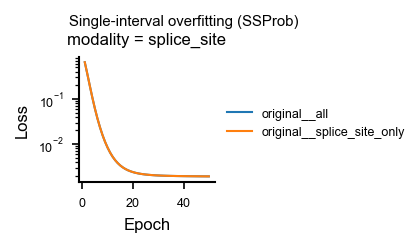

In [9]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_site_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name",
    col="modality",
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.1
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

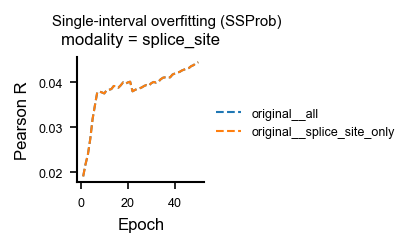

In [10]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_site_auprc_macro"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name",
    col="modality",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Pearson R"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

### splice site head is not influenced by segmentation or lack of annotated splice sites

In [11]:
X = logs.query("run_name.isin(['debug_splice_sites__randinit_seg_nogtf__all','debug_splice_sites__randinit_noseg_gtf__all','debug_splice_sites__randinit_seg_gtf__all','original__all']) & density=='medium'")

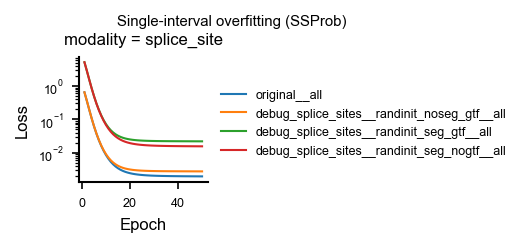

In [12]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_site_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name",
    col="modality",
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.1
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

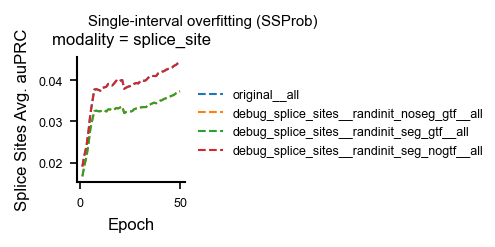

In [13]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_site_auprc_macro"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name",
    col="modality",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Splice Sites Avg. auPRC"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

### pretrained splice site head is influenced by segmentation and lack of annotated splice sites

In [32]:
X = logs#.query("run_name.isin(['debug_splice_sites__pretrinit_seg_nogtf__all','debug_splice_sites__pretrinit_noseg_gtf__all','debug_splice_sites__pretrinit_seg_gtf__all','original__all']) & density=='medium'")

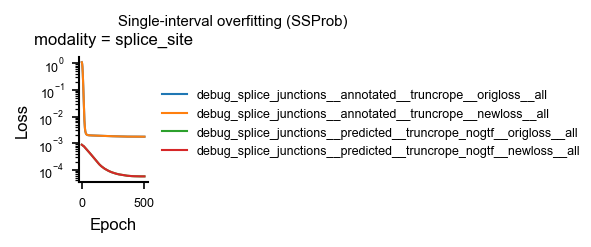

In [33]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_site_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name",
    col="modality",
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

In [34]:
X

,sample,epoch,train_loss,val_loss,learning_rate,is_best,timestamp,train_loss_rna_seq,train_loss_splice_site,train_loss_splice_usage,...,splice_site_auprc_acceptor_pos,splice_site_auprc_donor_neg,splice_site_auprc_acceptor_neg,splice_site_auprc_no_site,splice_site_auprc_macro,splice_site_auprc_weighted,epoch_wall_time_s,peak_gpu_mem_gb,run_name,density
0,NaN,1,12.859060,12.859060,5.000000e-05,True,2026-05-12T13:11:47.226092,2.865017,1.092571,0.740121,...,0.000033,0.000063,0.054645,0.999645,0.013699,0.009533,12.660243,30.932068,debug_splice_junctions__annotated__truncrope__...,medium
1,NaN,2,12.859060,12.540694,1.000000e-04,True,2026-05-12T13:11:58.656765,2.865017,1.092571,0.740121,...,0.000033,0.000064,0.055028,0.999653,0.013795,0.009600,6.043038,30.932068,debug_splice_junctions__annotated__truncrope__...,medium
2,NaN,3,12.540694,11.947271,1.500000e-04,True,2026-05-12T13:12:11.346085,2.851850,1.066893,0.733854,...,0.000033,0.000066,0.055642,0.999667,0.013949,0.009707,5.988338,30.932068,debug_splice_junctions__annotated__truncrope__...,medium
3,NaN,4,11.947271,11.216801,2.000000e-04,True,2026-05-12T13:12:25.418393,2.825719,1.016703,0.721369,...,0.000033,0.000071,0.057940,0.999687,0.014525,0.010107,5.868736,30.932068,debug_splice_junctions__annotated__truncrope__...,medium
4,NaN,5,11.216801,10.383596,2.500000e-04,True,2026-05-12T13:12:38.279814,2.787198,0.943476,0.703407,...,0.000033,0.000079,0.060211,0.999711,0.015095,0.010504,7.854601,30.932068,debug_splice_junctions__annotated__truncrope__...,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,NaN,496,3.587326,3.587278,1.713375e-07,False,2026-05-12T11:07:46.012042,1.529784,0.000057,0.283356,...,0.999744,0.946903,0.981045,1.000000,0.981868,0.984847,5.178290,30.932068,debug_splice_junctions__predicted__truncrope_n...,medium
1996,NaN,497,3.587278,3.587395,9.637976e-08,False,2026-05-12T11:07:51.400858,1.529784,0.000057,0.283356,...,0.999744,0.946903,0.981045,1.000000,0.981868,0.984847,5.172379,30.932068,debug_splice_junctions__predicted__truncrope_n...,medium
1997,NaN,498,3.587395,3.587372,4.283621e-08,False,2026-05-12T11:07:56.727163,1.529784,0.000057,0.283356,...,0.999744,0.946903,0.981045,1.000000,0.981868,0.984847,5.172741,30.932068,debug_splice_junctions__predicted__truncrope_n...,medium
1998,NaN,499,3.587372,3.587452,1.070917e-08,False,2026-05-12T11:08:02.515790,1.529784,0.000057,0.283356,...,0.999744,0.946903,0.981045,1.000000,0.981868,0.984847,5.636259,30.932068,debug_splice_junctions__predicted__truncrope_n...,medium


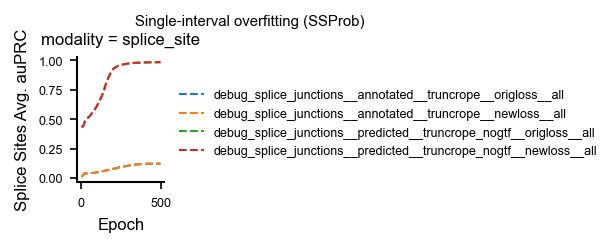

In [35]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_site_auprc_macro"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name",
    col="modality",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Splice Sites Avg. auPRC"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

### overfitting of splice junction head is not influenced by other heads

In [36]:
X = logs#.query("run_name.isin(['original__splice_junctions_only','original__all']) & density=='medium'")

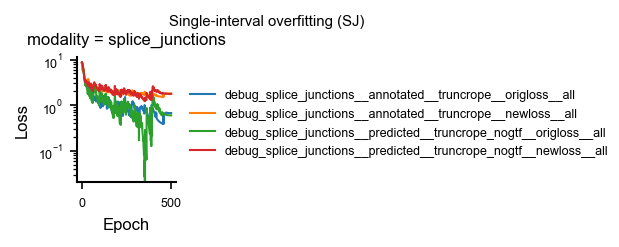

In [37]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name",
    col="modality",
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.1
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

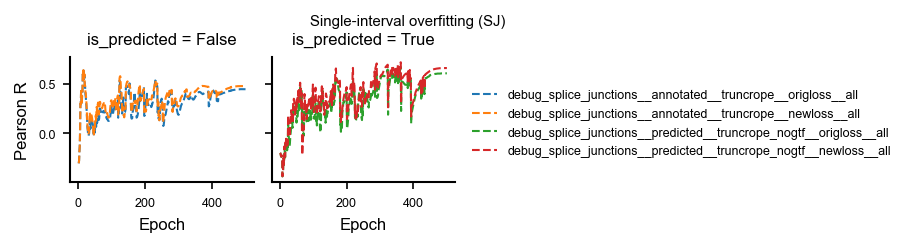

In [ ]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)
x["is_predicted"] = x["run_name"].str.contains("predicted")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name",
    col="is_predicted",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Pearson R"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

### splice junction head is affected by rope initialization

In [20]:
runs_oi = [
    "debug_splice_junctions__annotated__origrope__origloss__all",
    "debug_splice_junctions__annotated__truncrope__origloss__all",
    "debug_splice_junctions__predicted__origrope_nogtf__origloss__all",
]
X = logs[logs["run_name"].isin(runs_oi)].copy()

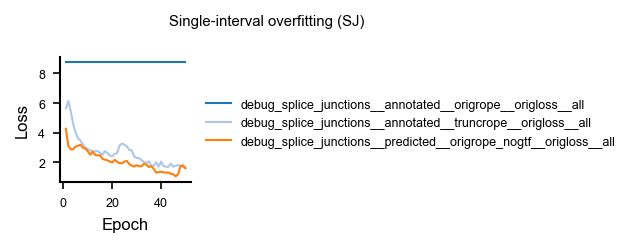

In [21]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)
x["is_truncrope"] = x["run_name"].str.contains("truncrope")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name", palette="tab20",
    linewidth=1,
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=1.2
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="linear",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

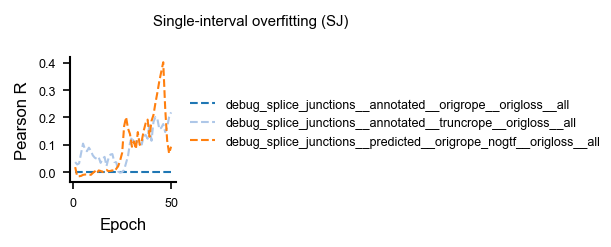

In [22]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)
x["is_truncrope"] = x["run_name"].str.contains("truncrope")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name", palette="tab20",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=1.2
)

g.set(
    xlabel="Epoch",
    ylabel="Pearson R"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

### splice junction head is affected by handling sparsity

In [23]:
runs_oi = [
    "debug_splice_junctions__annotated__truncrope__origloss__all",
    "debug_splice_junctions__annotated__truncrope__newloss__all",
    "debug_splice_junctions__predicted__origrope_nogtf__origloss__all",
    "debug_splice_junctions__predicted__origrope_nogtf__newloss__all",
]
X = logs[logs["run_name"].isin(runs_oi)].copy()

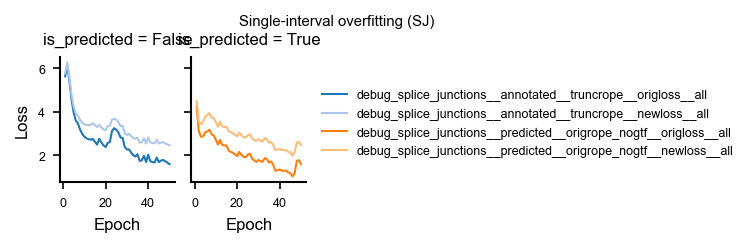

In [24]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)
x["is_predicted"] = x["run_name"].str.contains("predicted")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name", palette="tab20",
    col="is_predicted",
    linewidth=1,
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=0.8
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="linear",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

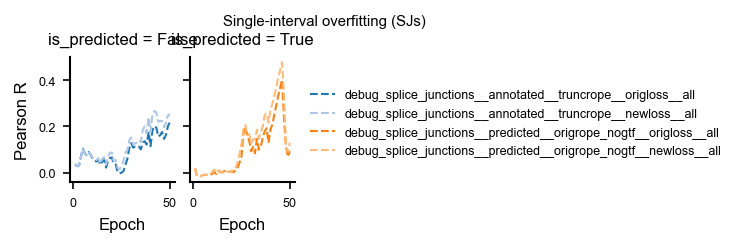

In [25]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)
x["is_predicted"] = x["run_name"].str.contains("predicted")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name", palette="tab20",
    col="is_predicted",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=0.8
)

g.set(
    xlabel="Epoch",
    ylabel="Pearson R"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJs)")

plt.show()